## Nonlinear Dynamics and Chaos
### Author: Łukasz Grzegrzółka

The aim of this laboratory session was to explore the behaviour of nonlinear dynamical systems and to illustrate how simple deterministic equations can give rise to extremely complex motion. Systems such as the Duffing oscillator and the Lorenz system are classical examples of models that exhibit deterministic chaos, meaning that their evolution is fully governed by differential equations, yet their trajectories are highly sensitive to initial conditions and can become effectively unpredictable over long times. A key theme of the exercises was to observe how nonlinearities, external forcing, and dissipation shape the long‑term dynamics, and how transitions from periodic motion to chaos can be detected using phase‑space plots and Poincaré‑type visualizations.

### The Duffing Oscillator - Definition and Physical Meaning

The Duffing oscillator is a classical example of a nonlinear dynamical system, originally introduced to model the motion of a mass attached to a nonlinear spring. Unlike the simple harmonic oscillator, whose restoring force is proportional to displacement, the Duffing oscillator includes an additional cubic term in the force, which makes the system strongly nonlinear. This nonlinearity leads to a wide range of behaviours, including periodic motion, multi‑periodic oscillations, and fully developed deterministic chaos.

Physically, the Duffing oscillator can represent systems with double‑well potentials, mechanical structures with geometric nonlinearities, magnetic systems, or electronic circuits. When the oscillator is additionally subjected to damping and a periodic external driving force, it becomes an excellent model for studying how nonlinear systems respond to external perturbations and how chaotic motion emerges from simple deterministic rules.

The equation of motion for the forced, damped Duffing oscillator is:

$\ddot{x} = b x - a x^3 - c \dot{x} + f \cos(2\pi \nu t)$,

where $x(t)$ is the displacement, $\dot{x}(t) = v(t)$ is the velocity, $a$ controls the strength of the nonlinear restoring force, $b$ determines the curvature of the potential wells, $c$ is the damping coefficient, $f$ is the amplitude of the periodic driving force, $\nu$ is the driving frequency.

For small amplitudes, the system behaves almost like a linear oscillator, but as the forcing increases, the nonlinear term becomes dominant. This leads to period‑doubling cascades, transitions between stable and unstable oscillations, and eventually chaotic trajectories that never repeat. Because of this rich behaviour, the Duffing oscillator is one of the standard models used to illustrate the fundamental mechanisms of chaos in nonlinear physics.

### Duffing Oscillator - Chaotic Regime

In the first part, the Duffing equation is integrated over a very long time interval using odeint, with parameters chosen to place the system deep inside the chaotic regime. The solution is sampled densely, and the resulting phase‑space portrait  $(x(t), v(t))$ is plotted as a scatter plot. Instead of forming a closed curve, as in a linear oscillator, the points fill a broad, irregular region of the phase plane. This structure reflects the presence of a strange attractor, where trajectories remain bounded but never repeat exactly. The dense, fractal‑like distribution of points demonstrates the hallmark of chaos: extreme sensitivity to initial conditions and the absence of periodicity, even though the system is fully deterministic.

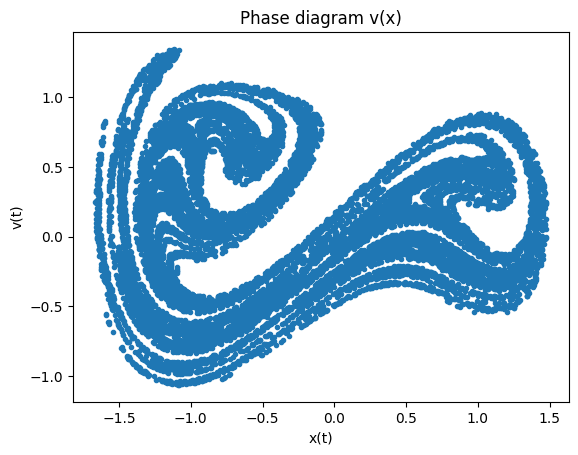

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

a=1
b=1
c=0.05
f=0.3
ni=0.2
t=np.arange(0, 20000)/ni
y0 = [0, 0.11]

def pend(y, t, a, b, c, f):
    x, v = y
    dydt = [v, b*x - a*(x**3) - c*v + f*np.cos(2*np.pi*ni*t)]
    return dydt

sol = odeint(pend, y0, t, args=(a, b, c, f))

x, v = sol[:, 0], sol[:, 1]
#x, v = sol[:, 0][4000:], sol[:, 1][4000:]


plt.scatter(x, v, marker=".")
plt.title("Phase diagram v(x)")
plt.xlabel("x(t)")
plt.ylabel("v(t)")
#plt.close()
plt.show()

### Duffing Oscillator - Period‑Doubling and the Onset of Chaos

The second code cell investigates how the Duffing oscillator behaves when the forcing amplitude is varied near the transition to chaos. After discarding the initial transient, the phase‑space trajectory is plotted for a long‑time segment. Depending on the value of the forcing parameter (f), the system may exhibit a single closed loop (period‑1 oscillation), a two‑loop structure (period‑2), or more complex multi‑loop patterns corresponding to higher‑order period‑doubling. As the forcing increases, these periodic structures eventually break down into a chaotic attractor. This behaviour illustrates the period‑doubling route to chaos, one of the most common mechanisms by which nonlinear systems lose stability and transition into chaotic motion. The resulting phase‑space curve provides a visual signature of this transition.

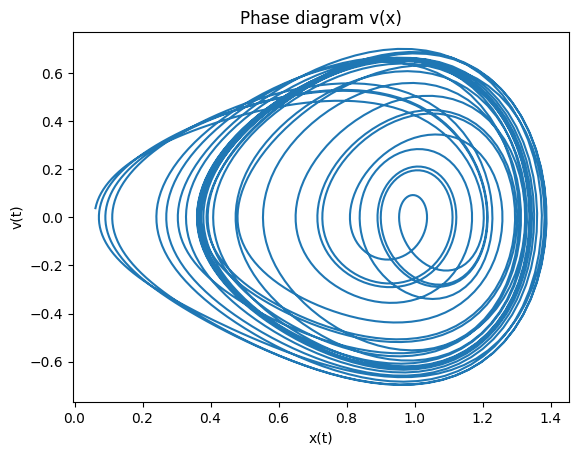

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# x' = v
# v' = b*x - a*(x**3) - c*v + f*np.cos(2*np.pi*t)

a=1
b=1
c=0.2
f=0.21
ni=0.2
t=np.linspace(0, 600, 10000)
y0 = [0, 0.11]

def pend(y, t, a, b, c, f):
    x, v = y
    dydt = [v, b*x - a*(x**3) - c*v + f*np.cos(2*np.pi*ni*t)]
    return dydt

sol = odeint(pend, y0, t, args=(a, b, c, f))


x, v = sol[:, 0][4000:], sol[:, 1][4000:]


plt.plot(x, v)
plt.title("Phase diagram v(x)")
plt.xlabel("x(t)")
plt.ylabel("v(t)")
#plt.close()
plt.show()


### Lorenz System - Three‑Dimensional Chaotic Trajectory

The third code cell solves the Lorenz equations, a simplified model of atmospheric convection that famously gave rise to the concept of the butterfly effect. With the classical parameter values $\sigma = 10$, $\rho = 25$, and $\beta = 8/3$, the system evolves toward the Lorenz attractor, a three‑dimensional strange attractor characterized by two lobes resembling butterfly wings. The plotted trajectory shows how the solution loops repeatedly around each lobe, switching irregularly between them. Although the motion remains confined to a finite region of phase space, it never settles into a periodic orbit. This illustrates the defining features of chaotic dynamics: bounded yet non‑repeating trajectories, sensitive dependence on initial conditions, and long‑term unpredictability despite the deterministic nature of the equations.

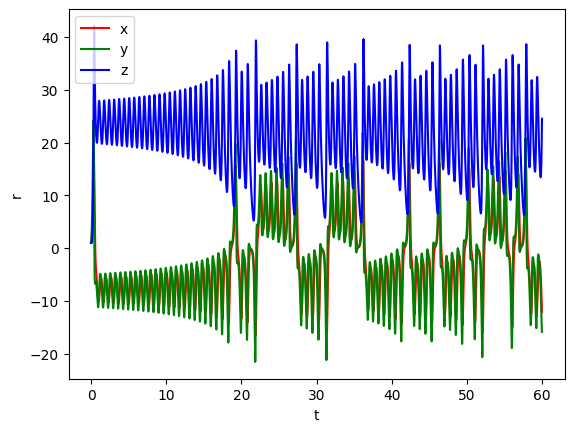

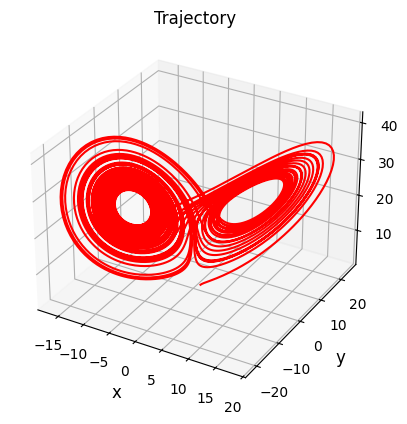

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from mpl_toolkits import mplot3d

sigma = 10
ro = 25
beta = 8/3
t = np.linspace(0, 60, 10000)

y0 = [1, 1, 1]

def Lorentz(y0, t, sigma=sigma, ro=ro, beta=beta):
    X, Y, Z = y0
    V = [sigma*(Y-X), X*(ro-Z)-Y, X*Y-beta*Z]
    return V

sol = odeint(Lorentz, y0, t)

x, y, z = sol[:, 0], sol[:, 1], sol[:,2]


plt.plot(t, x, "r",label="x")
plt.plot(t, y, "g",label="y")
plt.plot(t, z, "b",label="z")
plt.legend()
plt.xlabel("t")
plt.ylabel("r")
plt.show()


fig = plt.figure()
ax = plt.axes(projection ='3d')

ax.plot3D(x, y, z, 'red')
ax.set_title('Trajectory')
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('y', fontsize=12)
ax.set_zlabel('z', fontsize=12)
plt.show()